# JSON形式ファイルから座標を読み取って表示

## JSON形式ファイルを読み込むためのライブラリ

In [1]:
import json

## ファイルの読み込み

In [2]:
json_open = open('COCO_val2014_000000000589_keypoints.json', 'r')
json_load = json.load(json_open)

## peopleの中のpose_keypoints_2dの読み出し

In [3]:
print(json_load['people'][0]['pose_keypoints_2d'])

[436.439, 210.637, 0.938796, 444.309, 219.743, 0.928857, 431.2, 222.409, 0.915441, 463.862, 241.938, 0.930922, 484.728, 232.776, 0.804966, 459.933, 214.562, 0.874902, 488.643, 211.967, 0.716532, 480.818, 213.219, 0.79084, 432.486, 286.317, 0.888675, 419.459, 286.315, 0.856175, 393.358, 322.884, 0.895345, 369.891, 350.279, 0.93565, 444.283, 286.315, 0.844669, 471.653, 313.776, 0.858233, 449.488, 350.285, 0.919502, 433.835, 205.444, 0.961445, 441.662, 205.436, 0.949424, 0, 0, 0, 452.083, 205.413, 0.93917, 467.73, 362.025, 0.753715, 466.42, 359.41, 0.722527, 442.924, 351.629, 0.859091, 352.928, 356.849, 0.858612, 351.6, 351.618, 0.895102, 371.15, 354.239, 0.828776]


## pose_keypoints_2dの整理

In [4]:
kps = json_load['people'][0]['pose_keypoints_2d']
for i in range(0,3*24+1,3):
    print(i//3, kps[i],kps[i+1],kps[i+2])

0 436.439 210.637 0.938796
1 444.309 219.743 0.928857
2 431.2 222.409 0.915441
3 463.862 241.938 0.930922
4 484.728 232.776 0.804966
5 459.933 214.562 0.874902
6 488.643 211.967 0.716532
7 480.818 213.219 0.79084
8 432.486 286.317 0.888675
9 419.459 286.315 0.856175
10 393.358 322.884 0.895345
11 369.891 350.279 0.93565
12 444.283 286.315 0.844669
13 471.653 313.776 0.858233
14 449.488 350.285 0.919502
15 433.835 205.444 0.961445
16 441.662 205.436 0.949424
17 0 0 0
18 452.083 205.413 0.93917
19 467.73 362.025 0.753715
20 466.42 359.41 0.722527
21 442.924 351.629 0.859091
22 352.928 356.849 0.858612
23 351.6 351.618 0.895102
24 371.15 354.239 0.828776


## データをグラフで表示

In [5]:
import matplotlib.pyplot as plt

## つながりの定義

In [6]:
cnt = [(0,1),(1,2),(2,3),(3,4),(1,5),(5,6),(6,7),(1,8),
     (8,9),(9,10),(10,11),
     (8,12),(12,13),(13,14),
     (0,15),(0,16),(15,17),(16,18),
     (14,19),(19,20),(14,21),
     (11,22),(22,23),(11,24)]

## 表示

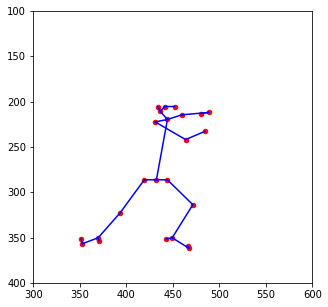

In [7]:
#グラフの設定
fig, ax = plt.subplots(figsize = (5,5))
ax.set_xlim([300,600])
ax.set_ylim([400,100])
#座標データの読み込み
kps = json_load['people'][0]['pose_keypoints_2d']
#点の表示
for i in range(0,3*24+1,3):
    if kps[i+2]>0:
        ax.scatter(kps[i],kps[i+1],c = 'red', marker='o', s=20)
#線の表示
for j in range(len(cnt)):
    i0 = cnt[j][0]*3
    i1 = cnt[j][1]*3
    if kps[i0+2]>0 and kps[i1+2]>0:
        ax.plot((kps[i0],kps[i1]),(kps[i0+1],kps[i1+1]),linestyle='solid',color='blue')
#plt.savefig('pose.pdf')#pdfで保存
#plt.savefig('pose.png')#pngで保存
plt.show()